# Static weighted random sampling vs dirichlet sampling

WRS is a static distribution of samples. Dirichlet is a dynamic distribution of samples. Both have the same mean distribution of classes. Dirichlet with a value around 10000x higher than WRS probabilities will result in a distribution that is similar to WRS. (ex: WRS 0.2, 0.3, 0.5 is comparable to Dirichlet 2000, 3000, 5000)

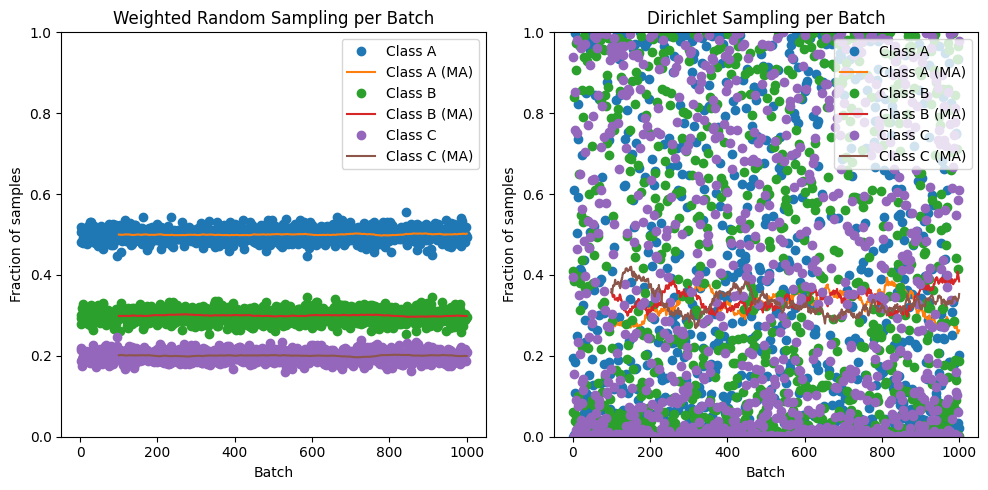

wrs
mean: [0.500121 0.299511 0.200368]
stdev: [0.01539592 0.01465646 0.01231278]
dir
mean: [0.322458 0.342146 0.335396]
stdev: [0.33955329 0.34632103 0.34360367]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Settings
classes = ['A', 'B', 'C']
num_batches = 1000
samples_per_batch = 1000

# Weighted Random Sampling probabilities
wrs_probs = np.array([0.5, 0.3, 0.2])

# Dirichlet Sampling concentration parameters
alpha = np.array([0.3, 0.3, 0.3])

# Collect batch class distributions
wrs_batches = []
dir_batches = []

for _ in range(num_batches):
    # WRS: sample each batch according to fixed probabilities
    wrs_sample = np.random.choice(classes, size=samples_per_batch, p=wrs_probs)
    wrs_counts = [np.sum(wrs_sample == c)/samples_per_batch for c in classes]
    wrs_batches.append(wrs_counts)
    
    # Dirichlet: sample probability vector then sample batch
    dir_p = np.random.dirichlet(alpha)
    dir_sample = np.random.choice(classes, size=samples_per_batch, p=dir_p)
    dir_counts = [np.sum(dir_sample == c)/samples_per_batch for c in classes]
    dir_batches.append(dir_counts)

wrs_batches = np.array(wrs_batches)
dir_batches = np.array(dir_batches)

n=100

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

# Plot
plt.figure(figsize=(10,5))
x = np.arange(1, num_batches+1)

plt.subplot(1,2,1)
for i, c in enumerate(classes):
    plt.plot(x, wrs_batches[:,i], marker='o', label=f'Class {c}', linestyle='none')
    plt.plot(x[(n-1):], moving_average(wrs_batches[:,i], n=n), marker='none', label=f'Class {c} (MA)', linestyle='-')

plt.title('Weighted Random Sampling per Batch')
plt.xlabel('Batch')
plt.ylabel('Fraction of samples')
plt.ylim(0,1)
plt.legend()

plt.subplot(1,2,2)
for i, c in enumerate(classes):
    plt.plot(x, dir_batches[:,i], marker='o', label=f'Class {c}', linestyle='none')
    plt.plot(x[(n-1):], moving_average(dir_batches[:,i], n=n), marker='none', label=f'Class {c} (MA)', linestyle='-')
plt.title('Dirichlet Sampling per Batch')
plt.xlabel('Batch')
plt.ylabel('Fraction of samples')
plt.ylim(0,1)
plt.legend()

plt.tight_layout()
plt.show()

# print(wrs_batches)
print('wrs')
print('mean:',np.mean(wrs_batches,0))
print('stdev:',np.std(wrs_batches,0))

# print(dir_batches)
print('dir')
print('mean:',np.mean(dir_batches,0))
print('stdev:',np.std(dir_batches,0))


# Dirichlet Partitioner

Testing dirichlet partitioner that is made by an open source company.

In [ ]:
from flwr_datasets.partitioner import DirichletPartitioner
from flwr_datasets import FederatedDataset
import counter

# Create the partitioner
dirichlet_partitioner = DirichletPartitioner(
    num_partitions=5,         # number of partitions (e.g., clients/domains)
    partition_by="label",       # label column name
    alpha=0.3,                  # Dirichlet concentration (smaller is more heterogeneous)
    min_partition_size=8000,     # minimum number of samples per partition
    self_balancing=True,        # optional balancing strategy
    shuffle=True,
    seed=42
)

# Load dataset with partitioner
fds = FederatedDataset(
    dataset="cifar10",
    partitioners={"train": dirichlet_partitioner}
)

# Load one partition
partition_0 = fds.load_partition(partition_id=0)
print(partition_0)

# Check all partition sizes
sizes = [
    len(fds.load_partition(i)) for i in range(dirichlet_partitioner.num_partitions)
]
print(sizes)

# Given above code, printing distributions:
[
    Counter(fds.load_partition(i)["label"])
    for i in range(5)
]

import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

num_partitions = 5
num_classes = 10

# Collect class distributions
distributions = []

for pid in range(num_partitions):
    partition = fds.load_partition(pid)
    labels = partition["label"]
    counter = Counter(labels)

    # Convert to ordered vector [count_class0, ..., count_class9]
    dist = [counter.get(i, 0) for i in range(num_classes)]
    distributions.append(dist)

distributions = np.array(distributions)

# Normalize to proportions
proportions = distributions / distributions.sum(axis=1, keepdims=True)

# Plot
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
axes = axes.flatten()

for i in range(num_partitions):
    axes[i].bar(range(num_classes), proportions[i])
    axes[i].set_title(f"Partition {i}")
    axes[i].set_xticks(range(num_classes))
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()


c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\site-packages\flwr_datasets\partitioner\dirichlet_partitioner.py:301: UserWarning: The specified min_partition_size (8000) was not satisfied for alpha ([np.float64(0.3)]) after 0 attempts at sampling from the Dirichlet distribution. The probability sampling from the Dirichlet distribution will be repeated. Note: This is not a desired behavior. It is recommended to adjust the alpha or min_partition_size instead. Generating partitions by sampling from a list of very wide range of alpha values can be hard to achieve. Try reducing the range between maximum (0.3) and minimum alpha (0.3) values or increasing all the values.
  warnings.warn(
c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\site-packages\flwr_datasets\partitioner\dirichlet_partitioner.py:301: UserWarning: The specified min_partition_size (8000) was not satisfied for alpha ([np.float64(0.3)]) after 1 attempts at sampling from the Dirichlet distribution. The pr

Dataset({
    features: ['img', 'label'],
    num_rows: 8239
})
[8239, 9572, 11181, 10484, 10524]


NameError: name 'Counter' is not defined

# Cosine Annealing LR test

Looking at how the learning rate changes after reaching 0. Some papers show it resetting back to 1 immediately while others show it rising back up continuing to follow the cosine function.

Conclusion: Unless reset, will continue to follow cosine.

C:\Users\naido\AppData\Local\Temp\ipykernel_33796\2906319942.py:18: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


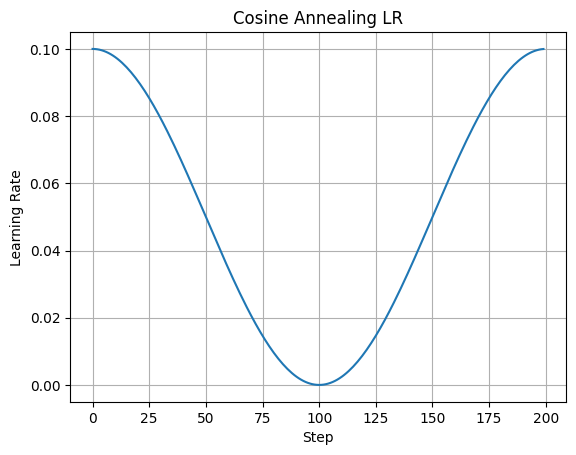

In [ ]:
import torch
import matplotlib.pyplot as plt

dummy_param = torch.nn.Parameter(torch.zeros(1))

optimizer = torch.optim.SGD([dummy_param], lr=0.1)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=100,
    
)

epochs = 200
lrs = []

for _ in range(epochs):
    lrs.append(optimizer.param_groups[0]["lr"])
    scheduler.step()

plt.plot(lrs)
plt.title("Cosine Annealing LR")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()